<a href="https://colab.research.google.com/github/buses19/computer-engineering-portfolio/blob/main/projects/fake-news-detection/Fake_News_Detection_and_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile

with zipfile.ZipFile("/content/archive (1).zip", "r") as zip_ref:
    zip_ref.extractall("news_data")


In [ ]:
import pandas as pd

# Load CSVs
fake_df = pd.read_csv("news_data/Fake.csv")
true_df = pd.read_csv("news_data/True.csv")

# Add labels
fake_df["label"] = "FAKE"
true_df["label"] = "REAL"

# Combine both
df = pd.concat([fake_df, true_df], ignore_index=True)


In [ ]:
print("Number of fake news samples:", len(fake_df))
print("Number of real news samples:", len(true_df))
print("Total number of samples:", len(df))

print("\nSamples per class:")
print(df["label"].value_counts())


Number of fake news samples: 23481
Number of real news samples: 21417
Total number of samples: 44898

Samples per class:
label
FAKE    23481
REAL    21417
Name: count, dtype: int64


In [ ]:
print("Columns in dataset:", df.columns.tolist())
print("Number of features (excluding label):", len(df.columns) - 1)


Columns in dataset: ['title', 'text', 'subject', 'date', 'label']
Number of features (excluding label): 4


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [ ]:
print("Data types of each column:")
print(df.dtypes)


Data types of each column:
title      object
text       object
subject    object
date       object
label      object
dtype: object


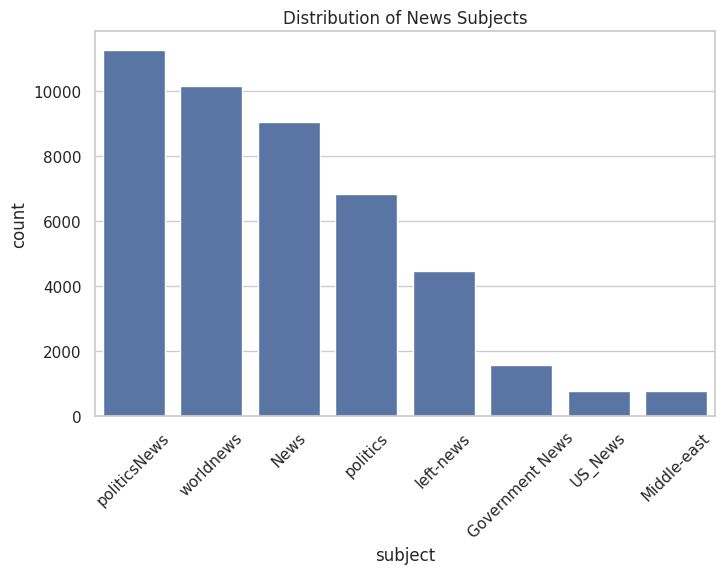

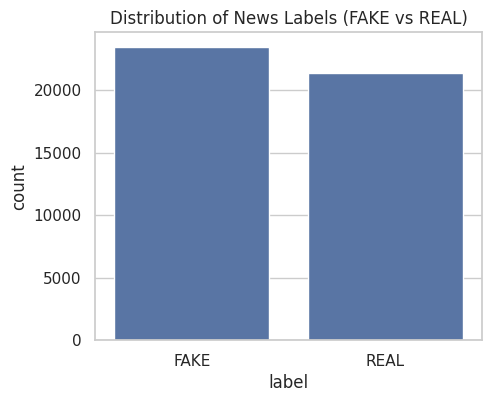

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Plot subject distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="subject", order=df["subject"].value_counts().index)
plt.title("Distribution of News Subjects")
plt.xticks(rotation=45)
plt.show()

# Plot label distribution
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="label")
plt.title("Distribution of News Labels (FAKE vs REAL)")
plt.show()


In [ ]:
# Create numerical features
df["title_length"] = df["title"].apply(len)
df["text_length"] = df["text"].apply(len)

# Show basic statistics
print(df[["title_length", "text_length"]].describe())


       title_length   text_length
count  44898.000000  44898.000000
mean      80.111720   2469.109693
std       25.379685   2171.617091
min        8.000000      1.000000
25%       63.000000   1234.000000
50%       73.000000   2186.000000
75%       91.000000   3105.000000
max      286.000000  51794.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoder
le = LabelEncoder()

# Encode 'label' column
df["label_encoded"] = le.fit_transform(df["label"])

# Show mapping
print("Label mapping:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# Sample
print(df[["label", "label_encoded"]].head())


Label mapping:
{'FAKE': np.int64(0), 'REAL': np.int64(1)}
  label  label_encoded
0  FAKE              0
1  FAKE              0
2  FAKE              0
3  FAKE              0
4  FAKE              0


In [ ]:
# Apply One-Hot Encoding to 'subject'
subject_ohe = pd.get_dummies(df["subject"], prefix="subject")

# Concatenate with original dataframe
df = pd.concat([df, subject_ohe], axis=1)

# Show first few columns after encoding
print(df[["subject"] + list(subject_ohe.columns)].head())


  subject  subject_Government News  subject_Middle-east  subject_News  \
0    News                    False                False          True   
1    News                    False                False          True   
2    News                    False                False          True   
3    News                    False                False          True   
4    News                    False                False          True   

   subject_US_News  subject_left-news  subject_politics  subject_politicsNews  \
0            False              False             False                 False   
1            False              False             False                 False   
2            False              False             False                 False   
3            False              False             False                 False   
4            False              False             False                 False   

   subject_worldnews  
0              False  
1              False  
2    

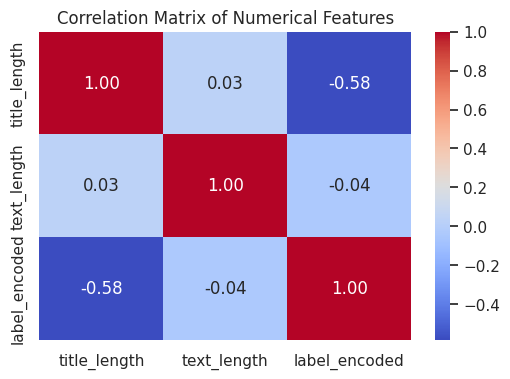

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features
numeric_features = df[["title_length", "text_length", "label_encoded"]]

# Compute correlation matrix
corr_matrix = numeric_features.corr()

# Display heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()
